In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from prophet import Prophet

# Configuração visual padrão para os gráficos do curso
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Ambiente 100% configurado e pronto para o curso!")


Ambiente 100% configurado e pronto para o curso!


In [19]:
# Carrega a base de dados configurando a coluna de tempo corretamente
df = pd.read_csv('Dados/bicicletas.csv')

# Exibe as 5 primeiras linhas para analisarmos a estrutura
df.head()


,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,Nublado,Não,Sim,Inverno
1,2015-01-04 01:00:00,138,NaN,NaN,93.0,5.0,Céu limpo,Não,Sim,Inverno
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,Céu limpo,Não,Sim,Inverno
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,Céu limpo,Não,Sim,Inverno
4,2015-01-04 04:00:00,47,NaN,NaN,93.0,6.5,Céu limpo,Não,Sim,Inverno


![Pipeline de Ciência de Dados](img/graf1.jpg)

## 🔄 Etapas do Ciclo de Desenvolvimento

O projeto segue as 6 fases metodológicas do pipeline de Ciência de Dados para garantir uma entrega orientada a resultados:

### 1. Identificação
Foco no entendimento profundo do problema de negócio e alinhamento de expectativas.
* **Mapeamento:** Definição clara do objetivo final e do público-alvo do projeto.
* **Restrições:** Levantamento de limitações técnicas e mapeamento de dados disponíveis.
* **Entrega:** Contextualização robusta do problema e desenho da hipótese de solução.

### 2. Preparação
Fase dedicada à coleta inicial e ao diagnóstico estrutural da base de dados.
* **Auditoria:** Identificação de falhas, inconsistências e lacunas no conjunto de dados.
* **Planejamento:** Formulação das estratégias de análise com base nos tipos de variáveis.
* **Entrega:** Compreensão detalhada do potencial e das limitações das tabelas disponíveis.

### 3. Processamento
Execução da limpeza e transformação dos dados para elevar a qualidade do pipeline.
* **Tratamento:** Resolução de dados ausentes (*NaN*) e remoção de registros duplicados.
* **Tipagem:** Conversão de formatos de colunas (como transformação de textos para *datetime*).
* **Entrega:** Uma base de dados higienizada, consistente e pronta para modelagem.

### 4. Análise
Exploração estatística dos dados tratados em busca de insights acionáveis.
* **Mineração:** Descoberta de padrões ocultos, tendências temporais e anomalias.
* **Correlação:** Identificação de relações matemáticas e dependências entre as variáveis.
* **Entrega:** Descobertas relevantes ligadas diretamente ao comportamento de consumo.

### 5. Modelagem
Construção, treinamento e otimização dos algoritmos preditivos.
* **Validação:** Testes de hipóteses estatísticas para validar as premissas da análise.
* **Predição:** Desenvolvimento do modelo matemático focado em prever novos valores.
* **Ajuste:** Mensuração de desempenho e tunagem para otimização dos resultados.

### 6. Compartilhamento
Fase final de comunicação dos resultados e tradução técnica para o negócio.
* **Visualização:** Construção de gráficos claros, relatórios ou apresentações executivas.
* **Critérios:** Adaptação da mensagem de acordo com o público-alvo do projeto.
* **Entrega:** Solução prática e provada, gerando valor real para a tomada de decisão.


![Gráfico 2 - Análise](img/graf2.jpg)


In [20]:
df.head()


,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,Nublado,Não,Sim,Inverno
1,2015-01-04 01:00:00,138,NaN,NaN,93.0,5.0,Céu limpo,Não,Sim,Inverno
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,Céu limpo,Não,Sim,Inverno
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,Céu limpo,Não,Sim,Inverno
4,2015-01-04 04:00:00,47,NaN,NaN,93.0,6.5,Céu limpo,Não,Sim,Inverno


In [21]:
# Retorna a quantidade de linhas e colunas do DataFrame
df.shape



(17429, 10)

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17429 entries, 0 to 17428
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data_hora         17429 non-null  str    
 1   contagem          17429 non-null  int64  
 2   temperatura       17406 non-null  float64
 3   sensacao_termica  17406 non-null  float64
 4   umidade           17429 non-null  float64
 5   velocidade_vento  17429 non-null  float64
 6   clima             17429 non-null  str    
 7   feriado           17429 non-null  str    
 8   fim_de_semana     17429 non-null  str    
 9   estacao           17429 non-null  str    
dtypes: float64(4), int64(1), str(5)
memory usage: 1.3 MB


In [23]:
# Verifica a quantidade de valores nulos (ausentes) em cada coluna
df.isnull().sum()


data_hora            0
contagem             0
temperatura         23
sensacao_termica    23
umidade              0
velocidade_vento     0
clima                0
feriado              0
fim_de_semana        0
estacao              0
dtype: int64

In [24]:
# Preenche os valores ausentes de temperatura por interpolação linear
df['temperatura'] = df['temperatura'].interpolate(method='linear')
df['sensacao_termica'] = df['sensacao_termica'].interpolate(method='linear')


In [25]:
df.head(10)

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
0,2015-01-04 00:00:00,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno
1,2015-01-04 01:00:00,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno
2,2015-01-04 02:00:00,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno
3,2015-01-04 03:00:00,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno
4,2015-01-04 04:00:00,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno
5,2015-01-04 05:00:00,46,2.00,2.00,93.0,4.0,Céu limpo,Não,Sim,Inverno
6,2015-01-04 06:00:00,51,1.00,-1.00,100.0,7.0,Parcialmente nublado,Não,Sim,Inverno
7,2015-01-04 07:00:00,75,1.00,-1.00,100.0,7.0,Parcialmente nublado,Não,Sim,Inverno
8,2015-01-04 08:00:00,131,1.50,-1.00,96.5,8.0,Parcialmente nublado,Não,Sim,Inverno
9,2015-01-04 09:00:00,301,2.00,-0.50,100.0,9.0,Nublado,Não,Sim,Inverno


In [26]:
# Retorna a quantidade total de linhas duplicadas no DataFrame
df.duplicated().sum()


np.int64(15)

In [27]:
# Identifica todas as ocorrências de linhas duplicadas, marcando todas como True
df.duplicated(keep=False)


0        False
1        False
2        False
3        False
4        False
         ...  
17424     True
17425     True
17426     True
17427     True
17428     True
Length: 17429, dtype: bool

In [28]:
# Armazena em uma variável uma máscara booleana que identifica todas as linhas duplicadas
duplicatas = df.duplicated(keep=False)


In [29]:
# Filtra o DataFrame original e armazena os registros repetidos em uma nova variável
linhas_duplicadas = df[duplicatas]

# Exibe na tela a tabela contendo apenas as linhas duplicadas encontradas
linhas_duplicadas


,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
519,2015-01-25 16:00:00,1238,8.0,5.0,71.0,18.0,Nublado,Não,Sim,Inverno
869,2015-02-09 06:00:00,479,5.0,3.5,87.0,6.5,Parcialmente nublado,Não,Não,Inverno
3655,2015-06-05 18:00:00,3411,23.0,23.0,50.0,26.0,Parcialmente nublado,Não,Não,Verão
4167,2015-06-27 02:00:00,337,15.5,15.5,74.5,18.0,Parcialmente nublado,Não,Sim,Verão
4658,2015-07-17 14:00:00,1882,24.5,24.5,44.0,29.5,Parcialmente nublado,Não,Não,Verão
5360,2015-08-15 23:00:00,759,17.0,17.0,59.0,6.0,Céu limpo,Não,Sim,Verão
8174,2015-12-12 11:00:00,1100,12.0,12.0,82.0,20.0,Chuva leve,Não,Sim,Inverno
8175,2015-12-12 12:00:00,1308,13.0,13.0,77.0,26.0,Chuva leve,Não,Sim,Inverno
8528,2015-12-27 05:00:00,57,15.0,15.0,72.0,31.0,Parcialmente nublado,Não,Sim,Inverno
9428,2016-02-02 17:00:00,2846,8.0,4.5,59.5,23.0,Parcialmente nublado,Não,Não,Inverno


In [30]:
# Ordena o DataFrame de registros repetidos cronologicamente pela coluna de tempo
linhas_duplicadas.sort_values(by='data_hora')


,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
519,2015-01-25 16:00:00,1238,8.0,5.0,71.0,18.0,Nublado,Não,Sim,Inverno
17422,2015-01-25 16:00:00,1238,8.0,5.0,71.0,18.0,Nublado,Não,Sim,Inverno
869,2015-02-09 06:00:00,479,5.0,3.5,87.0,6.5,Parcialmente nublado,Não,Não,Inverno
17417,2015-02-09 06:00:00,479,5.0,3.5,87.0,6.5,Parcialmente nublado,Não,Não,Inverno
3655,2015-06-05 18:00:00,3411,23.0,23.0,50.0,26.0,Parcialmente nublado,Não,Não,Verão
17425,2015-06-05 18:00:00,3411,23.0,23.0,50.0,26.0,Parcialmente nublado,Não,Não,Verão
4167,2015-06-27 02:00:00,337,15.5,15.5,74.5,18.0,Parcialmente nublado,Não,Sim,Verão
17421,2015-06-27 02:00:00,337,15.5,15.5,74.5,18.0,Parcialmente nublado,Não,Sim,Verão
4658,2015-07-17 14:00:00,1882,24.5,24.5,44.0,29.5,Parcialmente nublado,Não,Não,Verão
17418,2015-07-17 14:00:00,1882,24.5,24.5,44.0,29.5,Parcialmente nublado,Não,Não,Verão


In [31]:
# Remove as linhas duplicadas e armazena os dados tratados em um novo DataFrame
df_limpo = df.drop_duplicates()


In [32]:
# Retorna a quantidade de linhas e colunas do DataFrame limpo e sem duplicatas
df_limpo.shape


(17414, 10)

## 📁 Processamento e Higienização do Dataset

Finalizamos a primeira etapa de auditoria e garantia de qualidade da série temporal:

* **Volumetria Inicial:** O conjunto de dados bruto contava originalmente com **17.429 registros** e **10 variáveis**.
* **Imputação de Dados Ausentes:** Identificamos **23 valores nulos** nas variáveis `temperatura` e `sensacao_termica`. Aplicamos a técnica de **interpolação linear** (`interpolate`) para preencher as lacunas, preservando a continuidade física e meteorológica entre as horas adjacentes.
* **Auditoria de Duplicatas:** Isolamos e ordenamos cronologicamente **15 registros redundantes** pelo campo `data_hora`. Como cada linha representa uma assinatura temporal única de hora em hora, essas repetições foram classificadas como ruído de coleta.
* **Higienização Final:** Removemos as redundâncias permanentemente através do método `drop_duplicates()`, gerando o DataFrame tratado `df_limpo` para o início da modelagem preditiva.


In [33]:
# Gera um resumo estatístico das variáveis numéricas do DataFrame limpo
df_limpo.describe()


,contagem,temperatura,sensacao_termica,umidade,velocidade_vento
count,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000
mean,1143.101642,12.468206,11.521080,72.324954,15.913063
std,1085.108068,5.571670,6.614799,14.313186,7.894570
min,0.000000,-1.500000,-6.000000,20.500000,0.000000
25%,257.000000,8.000000,6.000000,63.000000,10.000000
50%,844.000000,12.500000,12.500000,74.500000,15.000000
75%,1671.750000,16.000000,16.000000,83.000000,20.500000
max,7860.000000,34.000000,34.000000,100.000000,56.500000


In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

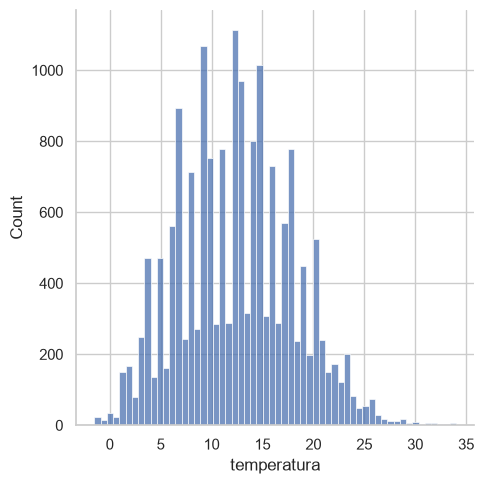

In [35]:
# Plota o gráfico de distribuição (histograma) para a variável de temperatura
sns.displot(df_limpo, x='temperatura')
plt.show()


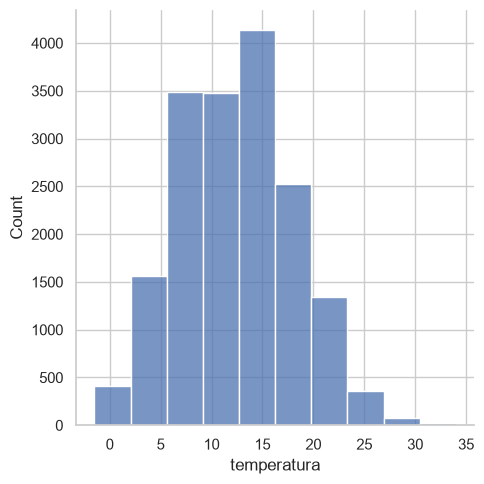

In [36]:
# Plota o histograma de temperatura agrupando os dados em 10 intervalos (bins)
sns.displot(df_limpo, x='temperatura', bins=10)
plt.show()


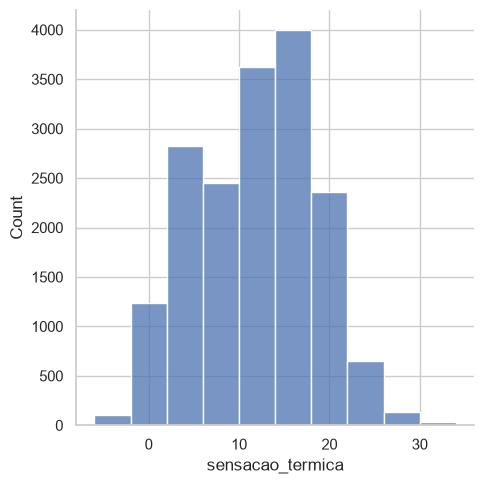

In [37]:
# Plota o histograma da sensação térmica agrupando os dados em 10 intervalos (bins)
sns.displot(df_limpo, x='sensacao_termica', bins=10)
plt.show()


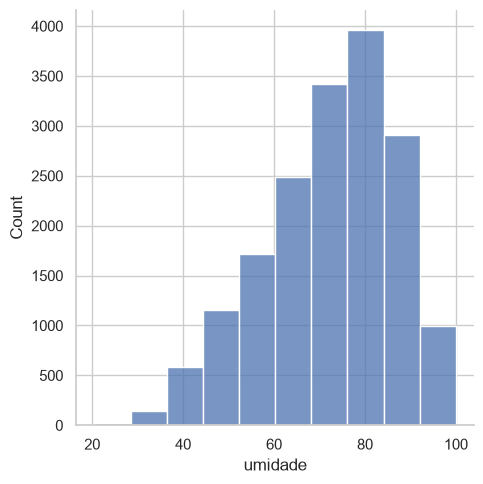

In [38]:
# Plota o histograma da umidade agrupando os dados em 10 intervalos (bins)
sns.displot(df_limpo, x='umidade', bins=10)
plt.show()


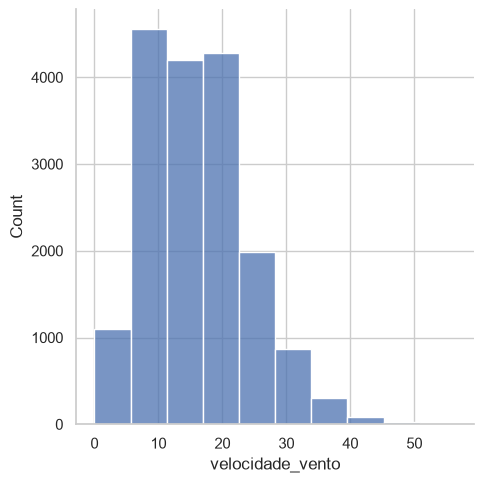

In [39]:
# Plota o histograma da velocidade do vento agrupando os dados em 10 intervalos (bins)
sns.displot(df_limpo, x='velocidade_vento', bins=10)
plt.show()


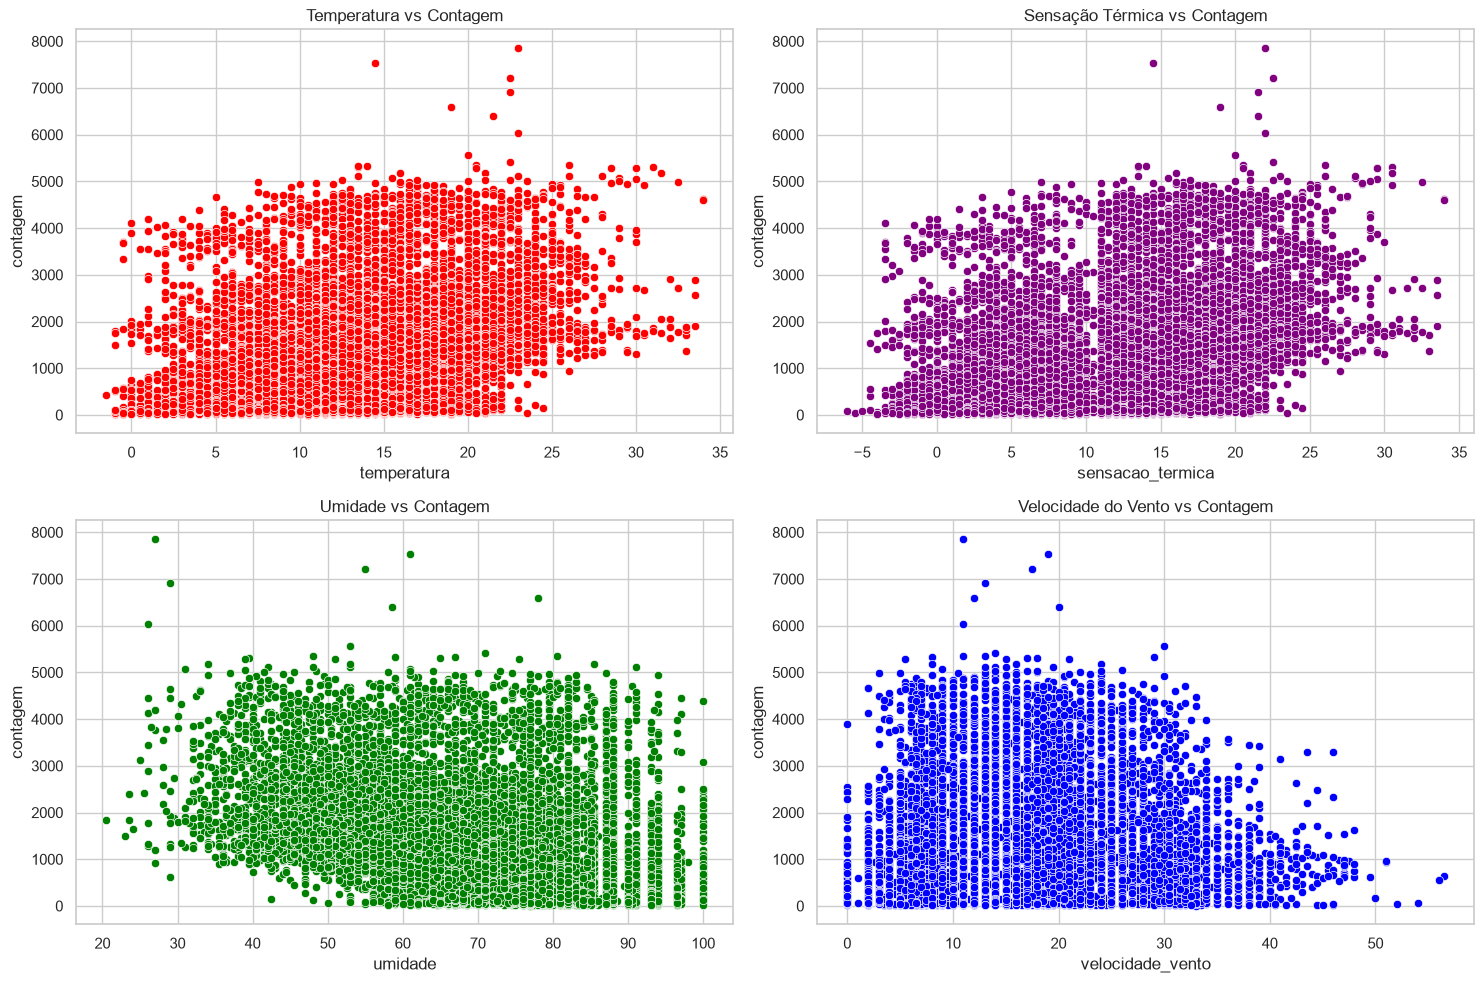

In [40]:
# prompt: crie 4 gráficos do tipo scatterplot das variáveis temperatura, sensacao_termica, umidade, velocidade_vento com a coluna contagem no eixo y. deixar os gráficos na posição 2X2. Cada gráfico deve ter um título.

# Create a figure and subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot the scatterplots
sns.scatterplot(ax=axes[0, 0], data=df_limpo, x='temperatura', y='contagem', color='red')
axes[0, 0].set_title('Temperatura vs Contagem')
sns.scatterplot(ax=axes[0, 1], data=df_limpo, x='sensacao_termica', y='contagem', color='purple')
axes[0, 1].set_title('Sensação Térmica vs Contagem')
sns.scatterplot(ax=axes[1, 0], data=df_limpo, x='umidade', y='contagem', color='green')
axes[1, 0].set_title('Umidade vs Contagem')
sns.scatterplot(ax=axes[1, 1], data=df_limpo, x='velocidade_vento', y='contagem', color='blue')
axes[1, 1].set_title('Velocidade do Vento vs Contagem')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

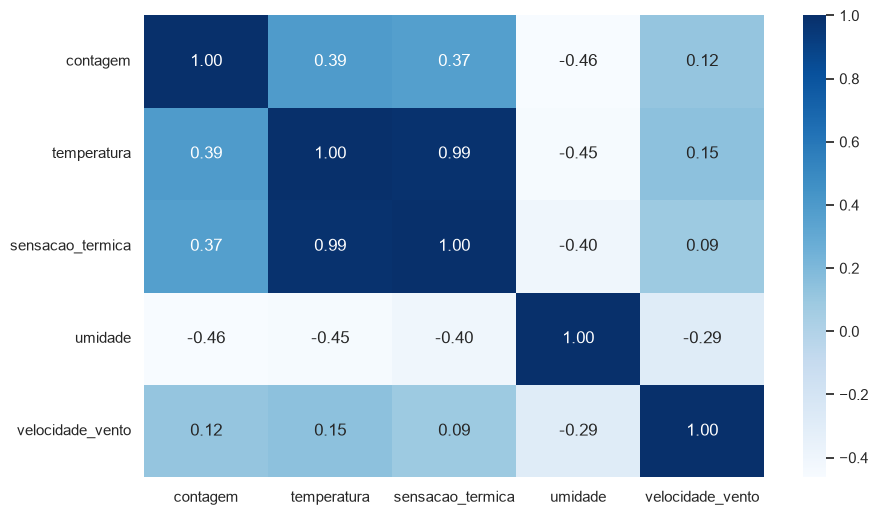

In [41]:
# Configura o tamanho da figura do mapa de calor
plt.figure(figsize=(10, 6))

# Plota a matriz de correlação linear entre as variáveis numéricas do projeto
sns.heatmap(df_limpo.corr(numeric_only=True), annot=True, cmap='Blues', fmt='.2f')

# Renderiza o mapa de calor na tela
plt.show()


## 📊 Análise Exploratória de Variáveis Numéricas

Concluímos a etapa de diagnóstico estatístico e mapeamento de relações bivariadas das características numéricas do dataset:

* **Estatística Descritiva:** Utilizamos o método `describe()` para consolidar as medidas de tendência central, dispersão e limites (médias, desvios padrões, mínimos e máximos) de todo o conjunto de dados higienizado.
* **Mapeamento de Distribuições Histográficas:** Construímos histogramas através do método `displot(bins=10)` para avaliar o comportamento populacional e a densidade das variáveis climáticas (`temperatura`, `sensacao_termica`, `umidade` e `velocidade_vento`).
* **Análise Espacial de Dispersão:** Desenvolvemos uma matriz de gráficos do tipo `scatterplot` na configuração 2X2. Essa visualização cruzou simultaneamente os fatores meteorológicos com a nossa variável alvo (`contagem`), permitindo rastrear visualmente zonas de alta densidade e comportamento de dispersão dos aluguéis.
* **Mensuração de Correlação Linear:** Calculamos a matriz de correlação estatística com o método `corr(numeric_only=True)` e a projetamos em um mapa de calor (`heatmap`). O gráfico quantificou numericamente a força do impacto de cada variável climática sobre a demanda de bicicletas, além de mapear a forte multicolinearidade entre temperatura real e sensação térmica.


In [43]:
# Gera um resumo estatístico das variáveis categóricas (texto) do DataFrame
df_limpo.describe(include=[object])


C:\Users\vagne\AppData\Local\Temp\ipykernel_20940\3398452761.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_limpo.describe(include=[object])


,data_hora,clima,feriado,fim_de_semana,estacao
count,17414,17414,17414,17414,17414
unique,17414,6,2,2,4
top,2015-01-04 00:00:00,Céu limpo,Não,Não,Primavera
freq,1,6150,17030,12444,4394


In [44]:
# Percorre as colunas categóricas para listar todos os valores únicos de cada uma
for col in ['clima', 'feriado', 'fim_de_semana', 'estacao']:
    print(f'Coluna: {col}')
    print(df_limpo[col].unique())
    print('='*15, '\n')


Coluna: clima
<StringArray>
[             'Nublado',            'Céu limpo', 'Parcialmente nublado',
           'Chuva leve',                 'Neve',  'Chuva com trovoadas']
Length: 6, dtype: str

Coluna: feriado
<StringArray>
['Não', 'Sim']
Length: 2, dtype: str

Coluna: fim_de_semana
<StringArray>
['Sim', 'Não']
Length: 2, dtype: str

Coluna: estacao
<StringArray>
['Inverno', 'Primavera', 'Verão', 'Outono']
Length: 4, dtype: str



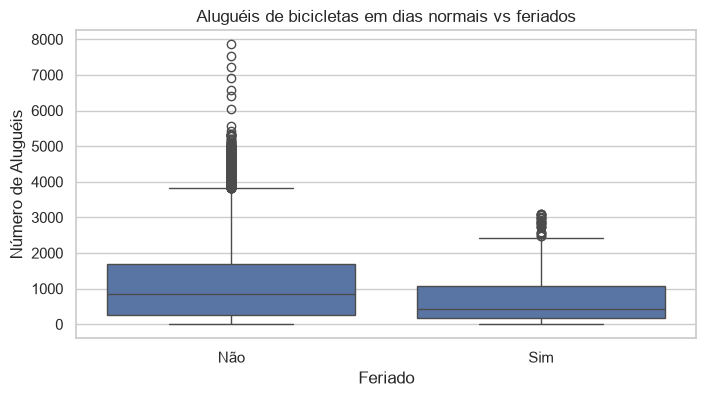

In [48]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='feriado', y='contagem', order=['Não', 'Sim'], data=df_limpo)
plt.title('Aluguéis de bicicletas em dias normais vs feriados')
plt.xlabel('Feriado')
plt.ylabel('Número de Aluguéis')
plt.show()

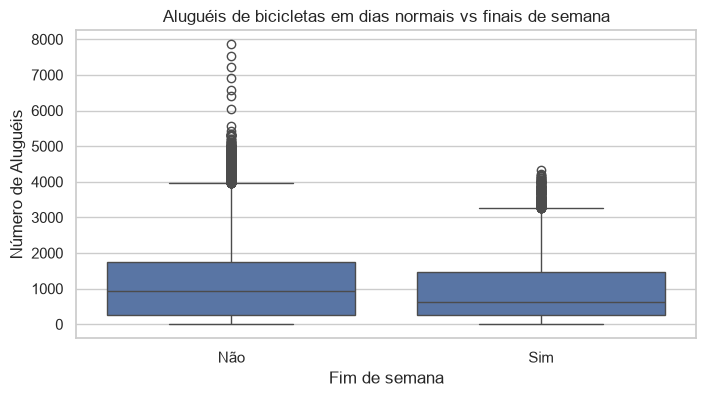

In [49]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='fim_de_semana', y='contagem', order=['Não', 'Sim'], data=df_limpo)
plt.title('Aluguéis de bicicletas em dias normais vs finais de semana')
plt.xlabel('Fim de semana')
plt.ylabel('Número de Aluguéis')
plt.show()

In [53]:
# Calcula a mediana de aluguéis agrupada por dias de feriado e dias normais
mediana_feriado = df_limpo.groupby('feriado')['contagem'].median()

# Calcula a mediana de aluguéis agrupada por finais de semana e dias úteis
mediana_fim_de_semana = df_limpo.groupby('fim_de_semana')['contagem'].median()


In [54]:
# Exibe na tela os valores de mediana calculados para os dias com e sem feriado
mediana_feriado


feriado
Não    855.0
Sim    439.5
Name: contagem, dtype: float64

In [55]:
# Exibe na tela os valores de mediana calculados para os dias úteis e finais de semana
mediana_fim_de_semana


fim_de_semana
Não    927.0
Sim    619.0
Name: contagem, dtype: float64

In [57]:
# Consolida o volume total de aluguéis agrupado por cada tipo de clima
df_clima = df_limpo.groupby('clima')['contagem'].sum()
df_clima


clima
Chuva com trovoadas        8168
Chuva leve              1526461
Céu limpo               7146847
Neve                      15051
Nublado                 4243887
Parcialmente nublado    6965558
Name: contagem, dtype: int64

In [67]:
# Agrupa pelo clima, calcula o volume total de aluguéis e transforma o índice em coluna
df_clima = df_limpo.groupby('clima')['contagem'].sum().reset_index()

# Exibe na tela a tabela estruturada com os totais de cada cenário climático
df_clima


,clima,contagem
0,Chuva com trovoadas,8168
1,Chuva leve,1526461
2,Céu limpo,7146847
3,Neve,15051
4,Nublado,4243887
5,Parcialmente nublado,6965558


In [68]:
# Consolida o volume total de aluguéis por clima, transforma em DataFrame e ordena do maior para o menor
df_clima = df_limpo.groupby('clima')['contagem'].sum().reset_index().sort_values(by='contagem', ascending=False)


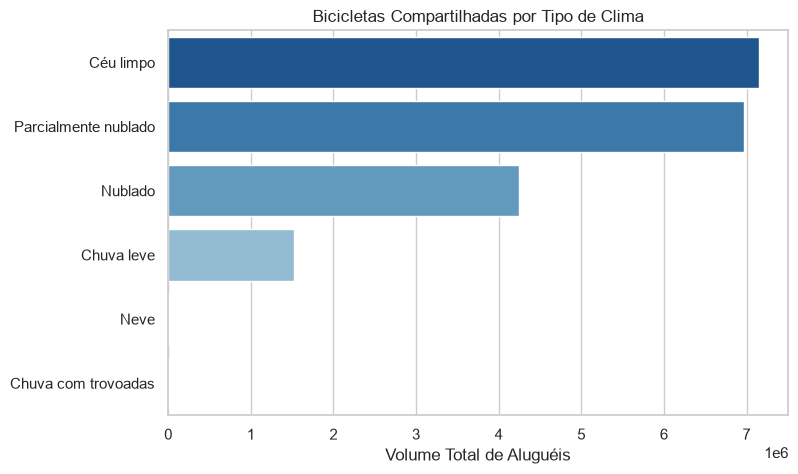

In [69]:
# Consolida a volumetria por clima, ordena de forma decrescente e armazena no DataFrame
df_clima = df_limpo.groupby('clima')['contagem'].sum().reset_index().sort_values(by='contagem', ascending=False)

# Define as dimensões da figura do gráfico
plt.figure(figsize=(8, 5))

# Plota o gráfico de barras horizontais ordenado com base na demanda de cada clima
sns.barplot(data=df_clima, y='clima', x='contagem', hue='clima', palette='Blues_r', orient='h', legend=False)

# Define o título principal e os rótulos dos eixos
plt.title('Bicicletas Compartilhadas por Tipo de Clima')
plt.xlabel('Volume Total de Aluguéis')
plt.ylabel('')

# Renderiza o gráfico final na tela
plt.show()


In [66]:
df_clima

,clima,contagem
2,Céu limpo,7146847
5,Parcialmente nublado,6965558
4,Nublado,4243887
1,Chuva leve,1526461
3,Neve,15051
0,Chuva com trovoadas,8168


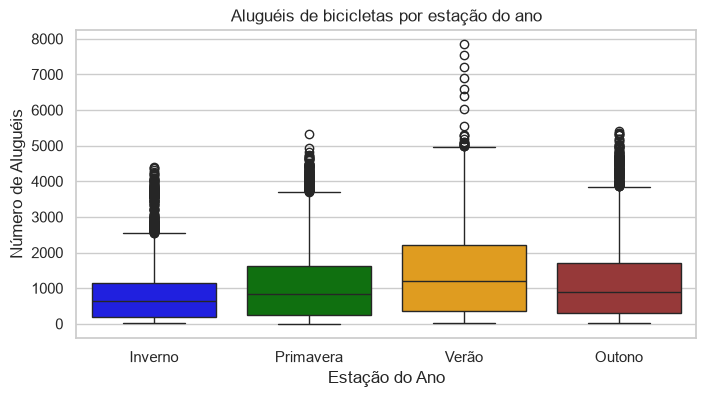

In [70]:
plt.figure(figsize=(8, 4))
paleta_cores = {'Primavera': 'green', 'Verão': 'orange', 'Outono': 'brown', 'Inverno': 'blue'}
sns.boxplot(x='estacao', y='contagem', data=df_limpo, hue='estacao', palette=paleta_cores)
plt.title('Aluguéis de bicicletas por estação do ano')
plt.xlabel('Estação do Ano')
plt.ylabel('Número de Aluguéis')
plt.show()

In [72]:
# Calcula a mediana de aluguéis de bicicletas agrupada por estação do ano
df_limpo.groupby('estacao')['contagem'].median()


estacao
Inverno       632.0
Outono        898.0
Primavera     823.0
Verão        1214.0
Name: contagem, dtype: float64

In [74]:
from scipy.stats import mannwhitneyu

primavera = df_limpo[df_limpo['estacao'] == 'Primavera']['contagem']
outono = df_limpo[df_limpo['estacao'] == 'Outono']['contagem']

u_statistic, p_value = mannwhitneyu(primavera, outono, alternative='two-sided')
u_statistic, p_value

(np.float64(9044682.5), np.float64(0.0004762100221646296))